## Analisis y Preprocesamiento Dataset

Se carga el Dataset para poder mostrar de que se trata y que caracteristicas tiene.

##### Problema
Se teine que preprocesar el dataset. Se encuentra en formato `.dat` son 9 personas con diferentes datos captados. es decir 9 .dat, ninguno estos dat tiene los encabezados de columna, por lo que hay que nombrar.


In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Con el README nombramos cada nombre de cada posicion de datos, son 54.
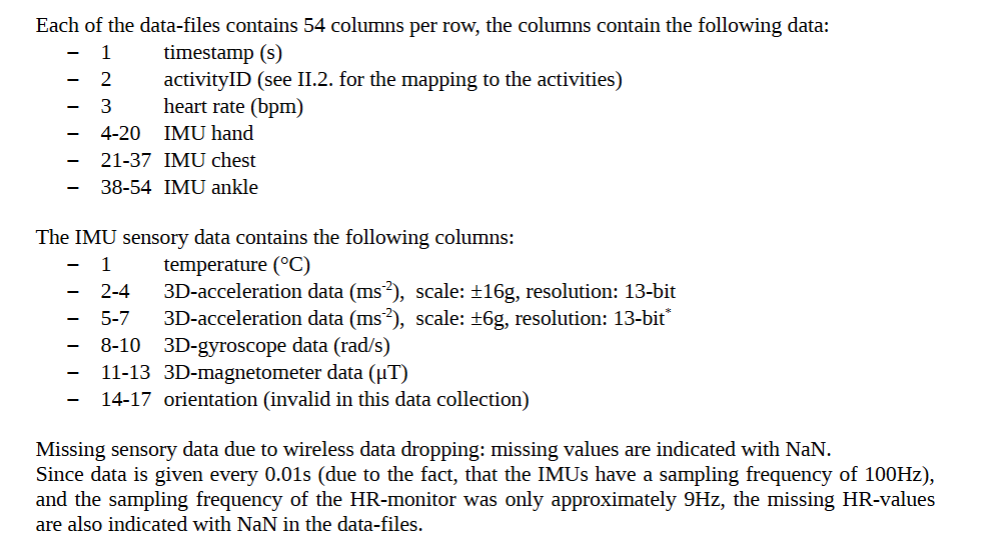

In [197]:
columnas = [
    "timestamp",
    "activity_id",
    "heart_rate",

    # MANO
    "hand_temperature",
    "hand_acc16_x",
    "hand_acc16_y",
    "hand_acc16_z",
    "hand_acc6_x",
    "hand_acc6_y",
    "hand_acc6_z",
    "hand_gyro_x",
    "hand_gyro_y",
    "hand_gyro_z",
    "hand_mag_x",
    "hand_mag_y",
    "hand_mag_z",
    "hand_orientation_1",
    "hand_orientation_2",
    "hand_orientation_3",
    "hand_orientation_4",

    # PECHO
    "chest_temperature",
    "chest_acc16_x",
    "chest_acc16_y",
    "chest_acc16_z",
    "chest_acc6_x",
    "chest_acc6_y",
    "chest_acc6_z",
    "chest_gyro_x",
    "chest_gyro_y",
    "chest_gyro_z",
    "chest_mag_x",
    "chest_mag_y",
    "chest_mag_z",
    "chest_orientation_1",
    "chest_orientation_2",
    "chest_orientation_3",
    "chest_orientation_4",

    # TOBILLO
    "ankle_temperature",
    "ankle_acc16_x",
    "ankle_acc16_y",
    "ankle_acc16_z",
    "ankle_acc6_x",
    "ankle_acc6_y",
    "ankle_acc6_z",
    "ankle_gyro_x",
    "ankle_gyro_y",
    "ankle_gyro_z",
    "ankle_mag_x",
    "ankle_mag_y",
    "ankle_mag_z",
    "ankle_orientation_1",
    "ankle_orientation_2",
    "ankle_orientation_3",
    "ankle_orientation_4"
]

In [198]:
print("Cantidad de columnas:")
len(columnas)

Cantidad de columnas:


54

### Prueba con primer Subject

Nombramos las columnas con el primer sujeto de prueba  `subject101.dat`

In [199]:
df = pd.read_csv(
    r"c:\Users\lucia\Desktop\IA 2\RNN,LSTM,GRU\PAMAP2_Dataset\Protocol\subject101.dat",
    sep=r"\s+",
    header=None,
    names=columnas
)


In [200]:
print("\nPrimeras filas:")
df.head()


Primeras filas:


,timestamp,activity_id,heart_rate,hand_temperature,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,...,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_orientation_1,ankle_orientation_2,ankle_orientation_3,ankle_orientation_4
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465,...,0.008300,0.009250,-0.017580,-61.1888,-38.9599,-58.1438,1.0,0.0,0.0,0.0
1,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207,...,-0.006577,-0.004638,0.000368,-59.8479,-38.8919,-58.5253,1.0,0.0,0.0,0.0
2,8.40,0,NaN,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280,...,0.003014,0.000148,0.022495,-60.7361,-39.4138,-58.3999,1.0,0.0,0.0,0.0
3,8.41,0,NaN,30.0,2.07473,8.52853,3.66021,2.33528,8.53622,3.73277,...,0.003175,-0.020301,0.011275,-60.4091,-38.7635,-58.3956,1.0,0.0,0.0,0.0
4,8.42,0,NaN,30.0,2.22936,8.83122,3.70000,2.23055,8.59741,3.76295,...,0.012698,-0.014303,-0.002823,-61.5199,-39.3879,-58.2694,1.0,0.0,0.0,0.0


In [201]:
print("\nDimensiones del sujeto 101:")
df.shape


Dimensiones del sujeto 101:


(376417, 54)

Verificamos quwe el tiempo que captura va incrementando 0.01 segundos
                    **100 observaciones por segundo = 100 Hz.**

In [202]:
print("\nDLos primero timeStamp:")
df["timestamp"].head(10)


DLos primero timeStamp:


0    8.38
1    8.39
2    8.40
3    8.41
4    8.42
5    8.43
6    8.44
7    8.45
8    8.46
9    8.47
Name: timestamp, dtype: float64

In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376417 entries, 0 to 376416
Data columns (total 54 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   timestamp            376417 non-null  float64
 1   activity_id          376417 non-null  int64  
 2   heart_rate           34389 non-null   float64
 3   hand_temperature     374963 non-null  float64
 4   hand_acc16_x         374963 non-null  float64
 5   hand_acc16_y         374963 non-null  float64
 6   hand_acc16_z         374963 non-null  float64
 7   hand_acc6_x          374963 non-null  float64
 8   hand_acc6_y          374963 non-null  float64
 9   hand_acc6_z          374963 non-null  float64
 10  hand_gyro_x          374963 non-null  float64
 11  hand_gyro_y          374963 non-null  float64
 12  hand_gyro_z          374963 non-null  float64
 13  hand_mag_x           374963 non-null  float64
 14  hand_mag_y           374963 non-null  float64
 15  hand_mag_z       

In [204]:
print("\n Cantidad y numero de actividades:")
df["activity_id"].value_counts().sort_index()


 Cantidad y numero de actividades:


activity_id
0     126460
1      27187
2      23480
3      21717
4      22253
5      21265
6      23575
7      20265
12     15890
13     14899
16     22941
17     23573
24     12912
Name: count, dtype: int64

Indicar que el ID es del sujeto 1 (101)
Importante al momento de abrir las metricas de los demas sujetos

In [205]:
df["subject_id"] = 101

In [206]:
df.shape

(376417, 55)

### Limpieza de columanas innecesarias

#### Limpieza de trasient activity `activityID=0`
recomendado por el readme del dataset
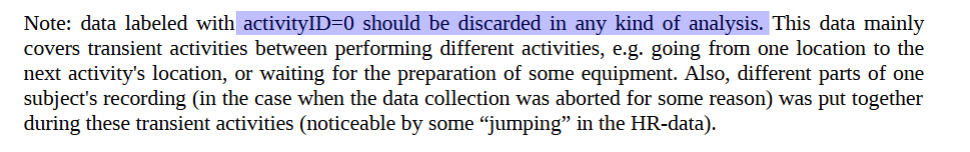

In [207]:
print("Antes:", df.shape)

Antes: (376417, 55)


In [208]:
df = df[df["activity_id"] != 0].copy()

In [209]:
print("Actual:", df.shape)

Actual: (249957, 55)


In [210]:
df["activity_id"].value_counts().sort_index()

activity_id
1     27187
2     23480
3     21717
4     22253
5     21265
6     23575
7     20265
12    15890
13    14899
16    22941
17    23573
24    12912
Name: count, dtype: int64

### Columanas de orentaciones
 
se eliminas 12 columnas de orentaciones de manos,pecho y tobillo que no sirve y el mis readme lo menciona
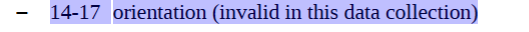

In [211]:
columnas_orientacion = [
    "hand_orientation_1",
    "hand_orientation_2",
    "hand_orientation_3",
    "hand_orientation_4",

    "chest_orientation_1",
    "chest_orientation_2",
    "chest_orientation_3",
    "chest_orientation_4",

    "ankle_orientation_1",
    "ankle_orientation_2",
    "ankle_orientation_3",
    "ankle_orientation_4"
]

df = df.drop(columns=columnas_orientacion)

In [212]:
df.shape

(249957, 43)

### Eliminar acelerómetros ±6g
Solo se matiene el acelerometro ±16g
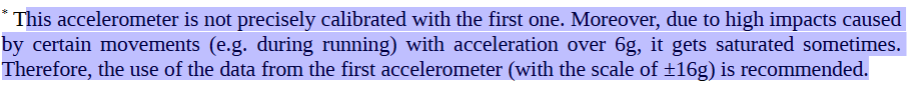

In [213]:
columnas_acc6 = [
    "hand_acc6_x",
    "hand_acc6_y",
    "hand_acc6_z",

    "chest_acc6_x",
    "chest_acc6_y",
    "chest_acc6_z",

    "ankle_acc6_x",
    "ankle_acc6_y",
    "ankle_acc6_z"
]

df = df.drop(columns=columnas_acc6)

31 características de sensores + `timestamp + activity_id + subject_id` = **34 columnas**.

In [214]:
df.shape

(249957, 34)

### Muestra de datos limpios
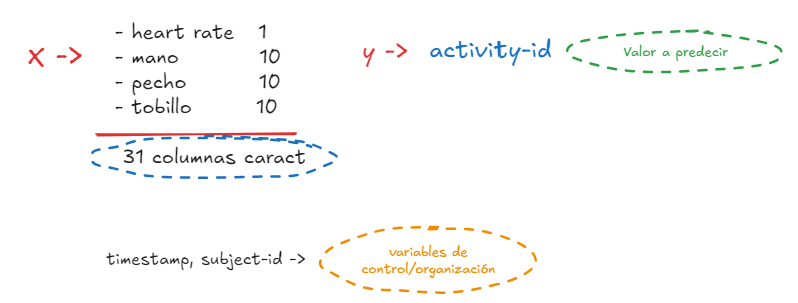

In [215]:
df.columns.tolist()

['timestamp',
 'activity_id',
 'heart_rate',
 'hand_temperature',
 'hand_acc16_x',
 'hand_acc16_y',
 'hand_acc16_z',
 'hand_gyro_x',
 'hand_gyro_y',
 'hand_gyro_z',
 'hand_mag_x',
 'hand_mag_y',
 'hand_mag_z',
 'chest_temperature',
 'chest_acc16_x',
 'chest_acc16_y',
 'chest_acc16_z',
 'chest_gyro_x',
 'chest_gyro_y',
 'chest_gyro_z',
 'chest_mag_x',
 'chest_mag_y',
 'chest_mag_z',
 'ankle_temperature',
 'ankle_acc16_x',
 'ankle_acc16_y',
 'ankle_acc16_z',
 'ankle_gyro_x',
 'ankle_gyro_y',
 'ankle_gyro_z',
 'ankle_mag_x',
 'ankle_mag_y',
 'ankle_mag_z',
 'subject_id']

### Analisis Valores Nulos


In [216]:
print(df.shape)

print("\nNulos:")
print(df.isnull().sum()[df.isnull().sum() > 0]
      .sort_values(ascending=False))

(249957, 34)

Nulos:
heart_rate           227111
hand_gyro_y            1358
hand_temperature       1358
hand_mag_y             1358
hand_mag_x             1358
hand_gyro_z            1358
hand_mag_z             1358
hand_gyro_x            1358
hand_acc16_z           1358
hand_acc16_y           1358
hand_acc16_x           1358
ankle_temperature      1098
ankle_mag_y            1098
ankle_mag_x            1098
ankle_gyro_z           1098
ankle_gyro_y           1098
ankle_gyro_x           1098
ankle_acc16_z          1098
ankle_acc16_y          1098
ankle_acc16_x          1098
ankle_mag_z            1098
chest_mag_z             326
chest_mag_y             326
chest_mag_x             326
chest_gyro_z            326
chest_gyro_y            326
chest_acc16_z           326
chest_acc16_y           326
chest_acc16_x           326
chest_temperature       326
chest_gyro_x            326
dtype: int64


No se puede eliminar Heart Rate, se hara una **interpolacion**

Estimaremos la transicion entre dos mediciones reales.
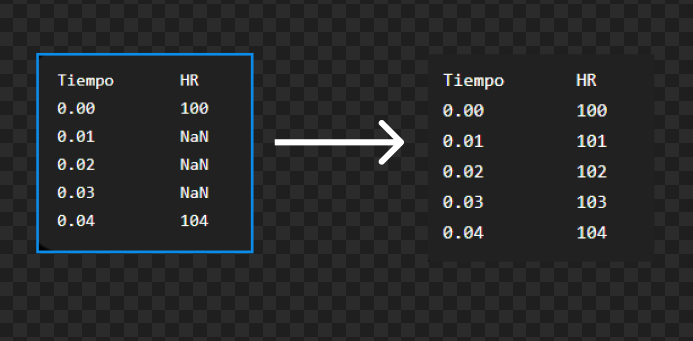

In [217]:
# 4. Interpolar valores faltantes
df = df.interpolate(method="linear", limit_direction="both")

In [218]:
# 5. Comprobar
print(df.shape)
print("Nulos restantes:", df.isnull().sum().sum())

(249957, 34)
Nulos restantes: 0


In [219]:
df.head(100)

,timestamp,activity_id,heart_rate,hand_temperature,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_gyro_x,hand_gyro_y,hand_gyro_z,...,ankle_acc16_x,ankle_acc16_y,ankle_acc16_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,subject_id
2928,37.66,1,100.0,30.375,2.21530,8.27915,5.58753,-0.004750,0.037579,-0.011145,...,9.73855,-1.84761,0.095156,0.002908,-0.027714,0.001752,-61.1081,-36.8636,-58.3696,101
2929,37.67,1,100.0,30.375,2.29196,7.67288,5.74467,-0.171710,0.025479,-0.009538,...,9.69762,-1.88438,-0.020804,0.020882,0.000945,0.006007,-60.8916,-36.3197,-58.3656,101
2930,37.68,1,100.0,30.375,2.29090,7.14240,5.82342,-0.238241,0.011214,0.000831,...,9.69633,-1.92203,-0.059173,-0.035392,-0.052422,-0.004882,-60.3407,-35.7842,-58.6119,101
2931,37.69,1,100.0,30.375,2.21800,7.14365,5.89930,-0.192912,0.019053,0.013374,...,9.66370,-1.84714,0.094385,-0.032514,-0.018844,0.026950,-60.7646,-37.1028,-57.8799,101
2932,37.70,1,100.0,30.375,2.30106,7.25857,6.09259,-0.069961,-0.018328,0.004582,...,9.77578,-1.88582,0.095775,0.001351,-0.048878,-0.006328,-60.2040,-37.1225,-57.8847,101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3023,38.61,1,101.0,30.375,2.91880,7.02995,6.52598,-0.035259,1.199900,0.334314,...,9.61668,-1.99620,-0.213888,-0.025557,-0.012077,0.001036,-61.6605,-37.0729,-57.7484,101
3024,38.62,1,101.0,30.375,2.47657,6.54393,6.94435,-0.317506,1.241120,0.251741,...,9.65650,-1.95911,-0.136531,0.008415,-0.041022,-0.007811,-61.2176,-36.9717,-58.2461,101
3025,38.63,1,101.0,30.375,2.31608,5.40659,6.90730,-0.586907,1.232010,0.185258,...,9.73666,-1.99916,0.057488,-0.004942,-0.010710,0.042854,-61.3395,-36.4126,-58.4867,101
3026,38.64,1,101.0,30.375,1.89132,4.68795,6.78790,-0.675568,1.205900,0.114739,...,9.65910,-1.88382,-0.059792,-0.012085,-0.020279,0.036443,-61.5587,-36.4130,-57.8660,101


### Limpieza y Carga de los 9 sujetos automaticamente

Creacion de una funcion para hacer todos los pasos automaticamente por cada .dat

In [220]:
def cargar_limpiar_sujeto(ruta, subject_id):
    df = pd.read_csv(ruta,sep=r"\s+",header=None,names=columnas)

    # Agregar identificador del sujeto
    df["subject_id"] = subject_id

    # Eliminar actividades transitorias
    df = df[df["activity_id"] != 0].copy()

    # Eliminar orientaciones inválidas
    columnas_orientacion = [
        "hand_orientation_1","hand_orientation_2",
        "hand_orientation_3","hand_orientation_4",
        "chest_orientation_1","chest_orientation_2",
        "chest_orientation_3","chest_orientation_4",
        "ankle_orientation_1","ankle_orientation_2",
        "ankle_orientation_3","ankle_orientation_4"
    ]

    df = df.drop(columns=columnas_orientacion)

    # Eliminar acelerómetros ±6g
    columnas_acc6 = [
        "hand_acc6_x","hand_acc6_y","hand_acc6_z",
        "chest_acc6_x","chest_acc6_y","chest_acc6_z",
        "ankle_acc6_x","ankle_acc6_y","ankle_acc6_z"
    ]

    df = df.drop(columns=columnas_acc6)

    # Interpolar datos faltantes
    df = df.interpolate(method="linear", limit_direction="both")

    return df

In [221]:
dataframes = []

for sujeto in range(101, 110):
    ruta = f"c:/Users/lucia/Desktop/IA 2/RNN,LSTM,GRU/PAMAP2_Dataset/Protocol/subject{sujeto}.dat"

    df_sujeto = cargar_limpiar_sujeto(ruta, sujeto)

    dataframes.append(df_sujeto)

    print(
        f"Sujeto {sujeto}:",
        df_sujeto.shape
    )

Sujeto 101: (249957, 34)
Sujeto 102: (263349, 34)
Sujeto 103: (174338, 34)
Sujeto 104: (231421, 34)
Sujeto 105: (272442, 34)
Sujeto 106: (250096, 34)
Sujeto 107: (232776, 34)
Sujeto 108: (262102, 34)
Sujeto 109: (6391, 34)


### Fusion Dataset

In [222]:
df_total = pd.concat(
    dataframes,
    ignore_index=True
)

print("Dataset completo:")
print(df_total.shape)

print(
    "Nulos:",
    df_total.isnull().sum().sum()
)

Dataset completo:
(1942872, 34)
Nulos: 0


In [223]:
print(df_total["activity_id"].value_counts().sort_index())

activity_id
1     192523
2     185188
3     189931
4     238761
5      98199
6     164600
7     188107
12    117216
13    104944
16    175353
17    238690
24     49360
Name: count, dtype: int64


In [224]:
print(
    "Cantidad de actividades:",
    df_total["activity_id"].nunique()
)

Cantidad de actividades: 12


Def de las 31 caracterisitcas

In [225]:
features = [
    col for col in df_total.columns
    if col not in [
        "timestamp",
        "activity_id",
        "subject_id"
    ]
]

print("Cantidad de características:")
print(len(features))

Cantidad de características:
31


### División Train / Validation / Test
NO se ahce aleatorio pruqe son series temporales.

In [226]:
train_df = df_total[
    df_total["subject_id"].isin([101, 102, 103, 104, 105, 106])
].copy()

val_df = df_total[
    df_total["subject_id"].isin([107, 108])
].copy()

test_df = df_total[
    df_total["subject_id"] == 109
].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (1441603, 34)
Validation: (494878, 34)
Test: (6391, 34)


#### Normalizacion

In [227]:
from sklearn.preprocessing import StandardScaler

features = [
    col for col in df_total.columns
    if col not in ["timestamp", "activity_id", "subject_id"]
]

print("Número de variables predictoras:", len(features))

Número de variables predictoras: 31


SOlo Train Porque el modelo no debe conocer información de Validation o Test antes de entrenar.

In [228]:
scaler = StandardScaler()

train_df[features] = scaler.fit_transform(train_df[features])

val_df[features] = scaler.transform(val_df[features])

test_df[features] = scaler.transform(test_df[features])

In [229]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

train_df["target"] = encoder.fit_transform(train_df["activity_id"])

val_df["target"] = encoder.transform(val_df["activity_id"])

test_df["target"] = encoder.transform(test_df["activity_id"])

print("Clases originales:")
print(encoder.classes_)

Clases originales:
[ 1  2  3  4  5  6  7 12 13 16 17 24]


### Secuencias Temporales

In [230]:
import numpy as np

def crear_secuencias(df, features, ventana=100):
    X = []
    y = []

    valores = df[features].values
    etiquetas = df["target"].values

    for i in range(0, len(df) - ventana, ventana):

        X.append(
            valores[i:i + ventana]
        )

        y.append(
            etiquetas[i + ventana - 1]
        )

    return np.array(X), np.array(y)

In [231]:
X_train, y_train = crear_secuencias(train_df, features)
X_val, y_val = crear_secuencias(val_df, features)
X_test, y_test = crear_secuencias(test_df, features)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (14416, 100, 31)
Validation: (4948, 100, 31)
Test: (63, 100, 31)


In [232]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

### Dataloader

In [233]:
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=64,
    shuffle=False
)

In [234]:
dataloader = {
    "train": train_loader,
    "val": val_loader
}

### RNN

In [235]:
class RNNModel(torch.nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()

        self.rnn = torch.nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = torch.nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        x, h = self.rnn(x)

        x = x[:, -1, :]

        return self.fc(x)

In [236]:
class LSTMModel(torch.nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()

        self.lstm = torch.nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = torch.nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        x, (h, c) = self.lstm(x)

        x = x[:, -1, :]

        return self.fc(x)

In [237]:
class GRUModel(torch.nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()

        self.gru = torch.nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = torch.nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        x, h = self.gru(x)

        x = x[:, -1, :]

        return self.fc(x)

### LSTM

In [238]:
class LSTMModel(torch.nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        num_classes,
        dropout=0.3
    ):

        super().__init__()

        self.lstm = torch.nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.dropout = torch.nn.Dropout(
            dropout
        )

        self.fc = torch.nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        x = output[:, -1, :]

        x = self.dropout(x)

        x = self.fc(x)

        return x

In [239]:
input_size = len(features)
hidden_size = 32
num_classes = len(encoder.classes_)

rnn = RNNModel(
    input_size,
    hidden_size,
    num_classes
)

lstm = LSTMModel(
    input_size,
    hidden_size,
    num_classes
)

gru = GRUModel(
    input_size,
    hidden_size,
    num_classes
)

In [240]:
def entrenar_modelo(
    model,
    train_loader,
    val_loader,
    epochs=20,
    lr=0.001,
    patience=3
):

    model.to()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = torch.nn.CrossEntropyLoss()

    historial = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    mejor_val_loss = float("inf")
    contador = 0

    for epoch in range(epochs):

        # =====================
        # ENTRENAMIENTO
        # =====================

        model.train()

        train_loss = 0
        correctos = 0
        total = 0

        for X, y in train_loader:

            X = X.to()
            y = y.to()

            optimizer.zero_grad()

            y_hat = model(X)

            loss = criterion(y_hat, y)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

            pred = y_hat.argmax(dim=1)

            correctos += (pred == y).sum().item()
            total += y.size(0)

        train_loss /= len(train_loader)
        train_acc = correctos / total

        # =====================
        # VALIDACIÓN
        # =====================

        model.eval()

        val_loss = 0
        correctos = 0
        total = 0

        with torch.no_grad():

            for X, y in val_loader:

                X = X.to()
                y = y.to()

                y_hat = model(X)

                loss = criterion(y_hat, y)

                val_loss += loss.item()

                pred = y_hat.argmax(dim=1)

                correctos += (pred == y).sum().item()
                total += y.size(0)

        val_loss /= len(val_loader)
        val_acc = correctos / total

        historial["train_loss"].append(train_loss)
        historial["val_loss"].append(val_loss)

        historial["train_acc"].append(train_acc)
        historial["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"loss: {train_loss:.4f} | "
            f"acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
        )

        # =====================
        # EARLY STOPPING
        # =====================

        if val_loss < mejor_val_loss:

            mejor_val_loss = val_loss
            contador = 0

        else:

            contador += 1

        if contador >= patience:

            print("Early stopping")
            break

    return historial

In [241]:
import torch
import torch.nn as nn

class ModeloGRU(nn.Module):
    def __init__(self, n_features, n_clases):
        super().__init__()
        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(128, n_clases)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])   # última salida temporal
        return out

# Crear el modelo
modelo_gru = ModeloGRU(n_features=31, n_clases=13)


In [242]:
hist_rnn = entrenar_modelo(
    rnn,
    train_loader,
    val_loader
)

Epoch 1/20 | loss: 1.5301 | acc: 0.5393 | val_loss: 1.4538 | val_acc: 0.5651
Epoch 2/20 | loss: 0.8410 | acc: 0.7496 | val_loss: 1.4728 | val_acc: 0.5643
Epoch 3/20 | loss: 0.6781 | acc: 0.7940 | val_loss: 1.4244 | val_acc: 0.6053
Epoch 4/20 | loss: 0.5710 | acc: 0.8335 | val_loss: 1.5893 | val_acc: 0.5928
Epoch 5/20 | loss: 0.5442 | acc: 0.8382 | val_loss: 1.3316 | val_acc: 0.6591
Epoch 6/20 | loss: 0.5009 | acc: 0.8497 | val_loss: 1.6624 | val_acc: 0.6045
Epoch 7/20 | loss: 0.5410 | acc: 0.8352 | val_loss: 1.7105 | val_acc: 0.5974
Epoch 8/20 | loss: 0.4434 | acc: 0.8714 | val_loss: 1.7724 | val_acc: 0.6027
Early stopping


In [243]:
hist_lstm = entrenar_modelo(
    lstm,
    train_loader,
    val_loader
)

Epoch 1/20 | loss: 1.6122 | acc: 0.5286 | val_loss: 1.3709 | val_acc: 0.5719
Epoch 2/20 | loss: 0.9219 | acc: 0.7236 | val_loss: 1.3296 | val_acc: 0.6055
Epoch 3/20 | loss: 0.7217 | acc: 0.8036 | val_loss: 1.3203 | val_acc: 0.6449
Epoch 4/20 | loss: 0.5955 | acc: 0.8410 | val_loss: 1.3111 | val_acc: 0.6863
Epoch 5/20 | loss: 0.4849 | acc: 0.8747 | val_loss: 1.4527 | val_acc: 0.6330
Epoch 6/20 | loss: 0.4616 | acc: 0.8767 | val_loss: 1.3804 | val_acc: 0.6465
Epoch 7/20 | loss: 0.4844 | acc: 0.8731 | val_loss: 1.3916 | val_acc: 0.6340
Early stopping


In [244]:
hist_gru = entrenar_modelo(
    gru,
    train_loader,
    val_loader
)

Epoch 1/20 | loss: 1.4666 | acc: 0.5812 | val_loss: 1.3993 | val_acc: 0.5532
Epoch 2/20 | loss: 0.6150 | acc: 0.8377 | val_loss: 1.3438 | val_acc: 0.5920
Epoch 3/20 | loss: 0.3715 | acc: 0.9077 | val_loss: 1.3263 | val_acc: 0.6176
Epoch 4/20 | loss: 0.2910 | acc: 0.9236 | val_loss: 1.3848 | val_acc: 0.6200
Epoch 5/20 | loss: 0.2380 | acc: 0.9387 | val_loss: 1.4679 | val_acc: 0.6013
Epoch 6/20 | loss: 0.2060 | acc: 0.9455 | val_loss: 1.6231 | val_acc: 0.5994
Early stopping


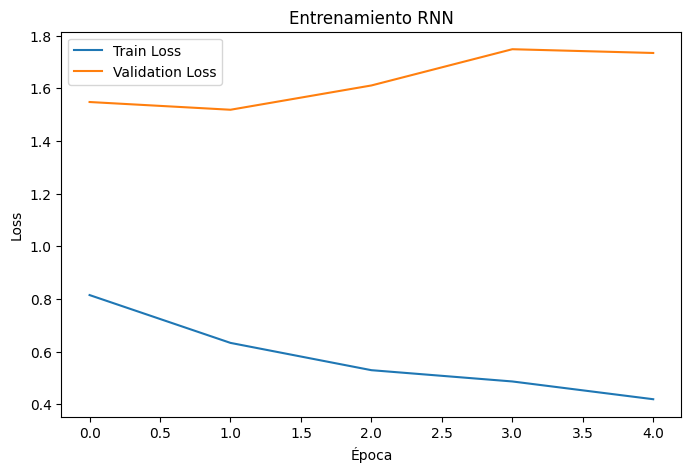

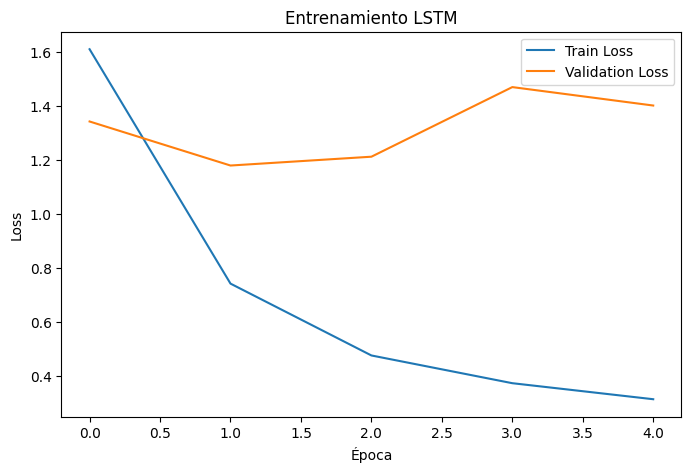

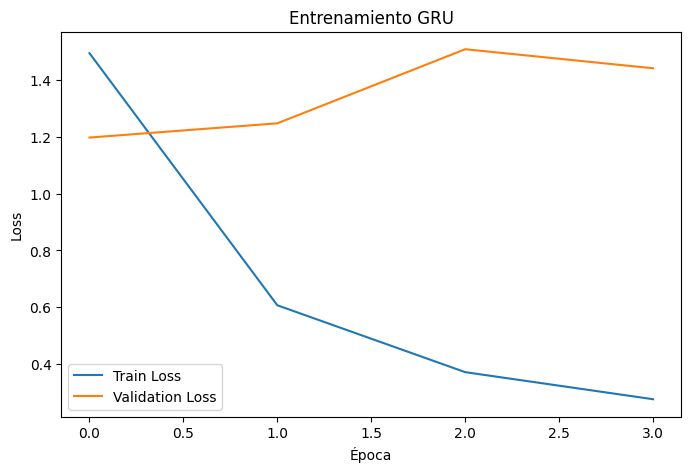

In [245]:
graficar_historial(
    historial_rnn,
    "RNN"
)

graficar_historial(
    historial_lstm,
    "LSTM"
)

graficar_historial(
    historial_gru,
    "GRU"
)

In [246]:
import matplotlib.pyplot as plt

def graficar_historial(historial, nombre):

    plt.figure(figsize=(8, 5))

    plt.plot(
        historial["train_loss"],
        label="Train Loss"
    )

    plt.plot(
        historial["val_loss"],
        label="Validation Loss"
    )

    plt.title(f"Entrenamiento {nombre}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

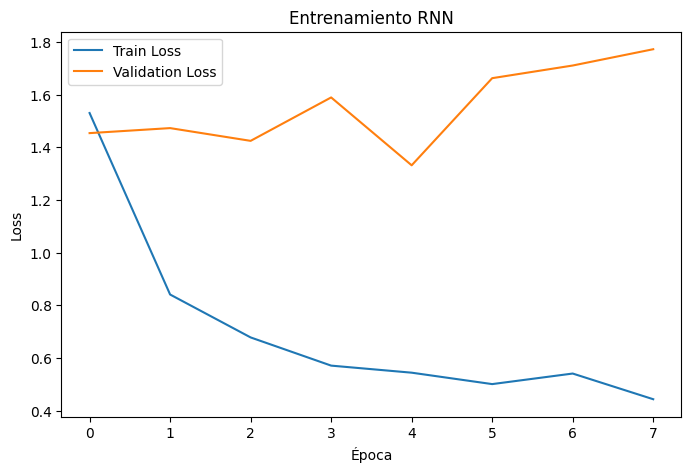

In [247]:
graficar_historial(
    hist_rnn,
    "RNN"
)

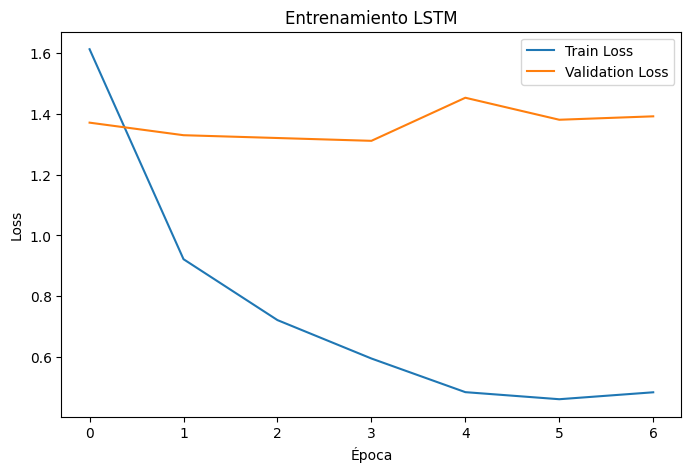

In [248]:
graficar_historial(
    hist_lstm,
    "LSTM"
)

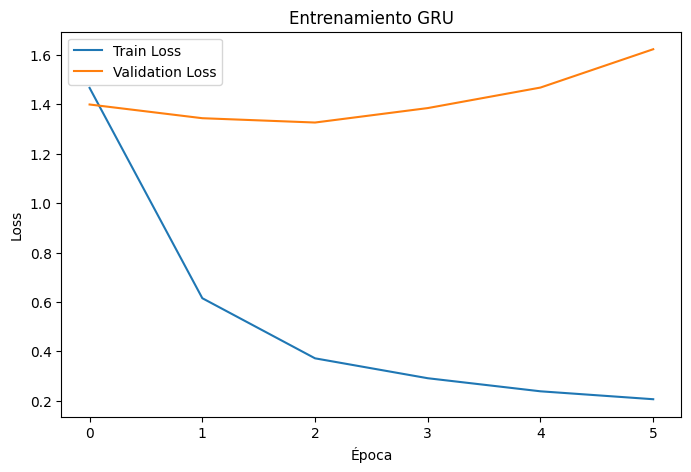

In [249]:
graficar_historial(
    hist_gru,
    "GRU"
)